In [31]:
#Here, we define the main packages and libraries to be utilized
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import *
import sympy
from sklearn.linear_model import LinearRegression
from sympy import re, im, I, E, symbols, exp
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import time

import tensorflow as tf

import glob
from tensorflow.keras.layers import Dense,Flatten,Cropping1D, Concatenate, MaxPooling1D, Dropout, Reshape, Conv1D, BatchNormalization, Activation, AveragePooling1D, GlobalAveragePooling1D, Lambda, Input, Concatenate, Add, UpSampling1D, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras import losses
from tensorflow.keras.losses import Hinge
from tensorflow.keras import backend as K
from tensorflow.keras.losses import binary_crossentropy, categorical_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard, ReduceLROnPlateau,LearningRateScheduler
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.models import Sequential
from sklearn.metrics import cohen_kappa_score, f1_score
from sklearn.model_selection import KFold, train_test_split

from scipy.special import legendre
from scipy.special import chebyt, chebyu



import numpy as np
from scipy.special import pro_ang1
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [32]:
# Define the architecture based on K
def Archit(K):
    """
    Generates an array representing a neural network architecture.

    Parameters:
    K : list or tuple
        K[0] - Number of layers (L)
        K[1] - Scaling factor for neurons per layer

    Returns:
    Lay_x_Neu : ndarray
        An array where each row represents (layer index, neurons in the layer).
    """

    # Create an array with values from 1 to K[0] (number of layers)
    Array = np.arange(1, K[0] + 1)

    # Create a 2D array with the structure (layer index, neurons in the layer)
    Lay_x_Neu = np.column_stack((Array, K[1] * Array))

    return Lay_x_Neu


In [33]:
#Number of samples and parameters

max_order_slep = 35 # increase to 20 or more eventually

Nsamples = [10000]
Ntest= [1000]
Nleast2= [1000]


#Para_slep = np.linspace(1, max_order_slep+1, 10).astype(int)
Para_slep= 9
Para_slep_list = list(range(0, Para_slep + 1))  # [0, 1, 2, ..., 10]
total_runs = 1


In [34]:
# Define the samples
def samps(t):

    Values = np.random.uniform(-1, 1, int(t[0]) if isinstance(t, (list, np.ndarray)) else int(t))


    #Ordenar os valores de mayor a menor
    #OValues = np.sort(Values)  # [::-1] invierte el orden

    return Values

In [35]:
#Returns the Slepian basis function

def NorSlep(j, c):
    b = 0 # Alpha parameter for the PSAF
    theta = np.linspace(-1, 1, 200)

    psaf_values = pro_ang1(b, j, c, theta)
    psaf_values = psaf_values[0]

    psaf_values = psaf_values[1:199]
    l2_norm = np.linalg.norm(psaf_values)/np.sqrt(len(theta)-1)


    return l2_norm

norms_ = np.zeros([Para_slep+1])
c=10
for k in range(Para_slep+1):
    norms_[k] = NorSlep(k, c)

In [36]:
norms_

array([0.534902  , 0.12490844, 0.39757555, 0.16843643, 0.37617846,
       0.22055052, 0.36646421, 0.22759574, 0.28154738, 0.20025422])

In [37]:
#Compute the PSWF with j and c at the value x.

def PSWF(x, j, c):

    b = 0 # Alpha parameter for the PSAF

    # Calculate the PSAF values for the two modes
    psaf_values = pro_ang1(b, j, c, x)
    psaf_values = psaf_values[0]



    l2_norm = norms_[j]

    return psaf_values/l2_norm

In [38]:
def create_simple_NN(X_samp, labels, L, activation='relu'):
    """
    Creates a simple feedforward neural network.

    Parameters:
    X_samp (array-like): Sample input data (not used in model definition).
    labels (array-like): Corresponding labels (not used in model definition).
    L (tuple or list): A tuple/list where L[0] is the number of hidden layers,
                       and L[1] is the number of neurons per layer.
    activation (str): Activation function for the hidden layers (default: 'relu').

    Returns:
    model (tf.keras.Model): A compiled Keras model with the specified architecture.
    """

    # Define the input layer with un solo feature
    model_input = Input(shape=(1,))

    # Inicializamos x con el input
    x = model_input

    # Create L[0] hidden layers with L[1] neurons each
    for i in range(2*L[0]):
        x = Dense(10*L[1], activation=activation,
                  kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.1))(x)

    # Define the output layer with a single neuron
    out = Dense(1)(x)

    # Create the model
    model = Model(inputs=model_input, outputs=out)

    return model


In [39]:
def create_fixed_NN():
    """
    Creates a neural network with fixed architecture (1, 100, 10, 1).

    Returns:
        model (tf.keras.Model): Keras model with architecture (1, 100, 10, 1)
    """

    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, Dense
    import tensorflow as tf

    # Input layer (1 feature)
    inputs = Input(shape=(1,))

    # Hidden layer 1: 200 neurons
    x = Dense(1000, activation='relu',
              kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.1))(inputs)

    # Hidden layer 2: 200 neurons
    x = Dense(1000, activation='relu',
              kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.1))(x)

    # Hidden layer 3: 10 neurons
    x = Dense(10, activation='relu',
              kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.1))(x)

    # Output layer: 1 neuron
    outputs = Dense(1)(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs)

    return model

In [40]:
def create_fixed_NN_he():
                inputs = Input(shape=(1,))
                x = Dense(1000, activation='relu',
                          kernel_initializer=tf.keras.initializers.HeNormal())(inputs)
                x = Dense(1000, activation='relu',
                          kernel_initializer=tf.keras.initializers.HeNormal())(x)
                x = Dense(10, activation='relu',
                          kernel_initializer=tf.keras.initializers.HeNormal())(x)
                outputs = Dense(1, kernel_initializer=tf.keras.initializers.GlorotUniform())(x)
                model = Model(inputs=inputs, outputs=outputs)
                return model

In [41]:
def create_fixed_NN_glorot():
                inputs = Input(shape=(1,))
                x = Dense(1000, activation='relu',
                          kernel_initializer=tf.keras.initializers.GlorotUniform())(inputs)
                x = Dense(1000, activation='relu',
                          kernel_initializer=tf.keras.initializers.GlorotUniform())(x)
                x = Dense(10, activation='relu',
                          kernel_initializer=tf.keras.initializers.GlorotUniform())(x)
                outputs = Dense(1, kernel_initializer=tf.keras.initializers.GlorotUniform())(x)
                model = Model(inputs=inputs, outputs=outputs)
                return model

In [42]:
# Parameters for training
initial_learning_rate = 0.001  # Initial learning rate
decay_steps = 1000             # Number of steps before applying the decay
decay_rate = 0.85              # Decay rate (rate at which learning rate is reduced)
staircase = True               # Whether the decay is discrete (staircase)

final_epochs = 1000       # Maximum number of epochs

VAL_SPLIT=0
BATCH_SIZE = 128

In [43]:
Lay_x_Neu = Archit((1,10))
Lay_x_Neu

array([[ 1, 10]])

In [44]:
#This is the function that we approximate
def funct(x):
    # t is the variable
    g = np.cos(10*x)*np.exp(-np.pi*x**2)


    return g

Run 0, 2L, 20N, j=0 → Test MSE = 0.0000000884
Train MSE = 0.0000000932


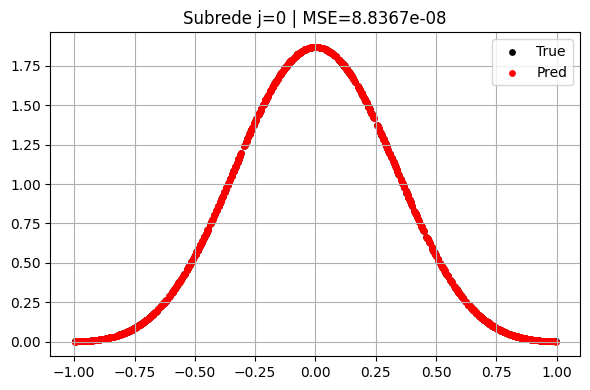

10.00% completado — ~1860.4s restantes

Run 0, 2L, 20N, j=1 → Test MSE = 0.0000003578
Train MSE = 0.0000004365


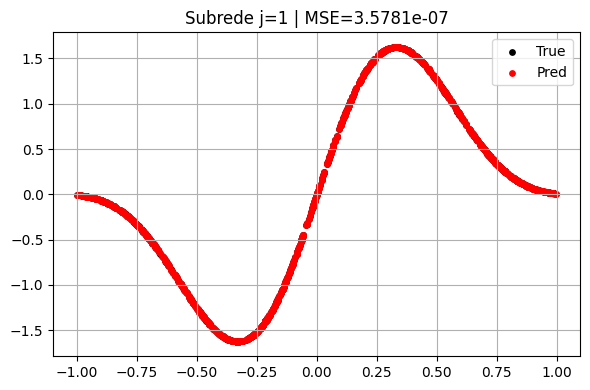

20.00% completado — ~1672.1s restantes

Run 0, 2L, 20N, j=2 → Test MSE = 0.0000007630
Train MSE = 0.0000008744


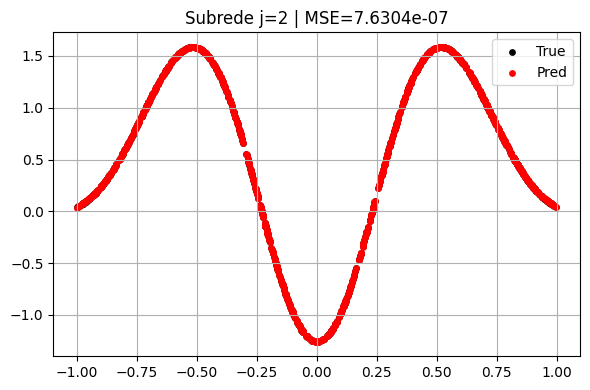

30.00% completado — ~1463.6s restantes

Run 0, 2L, 20N, j=3 → Test MSE = 0.0000002766
Train MSE = 0.0000002679


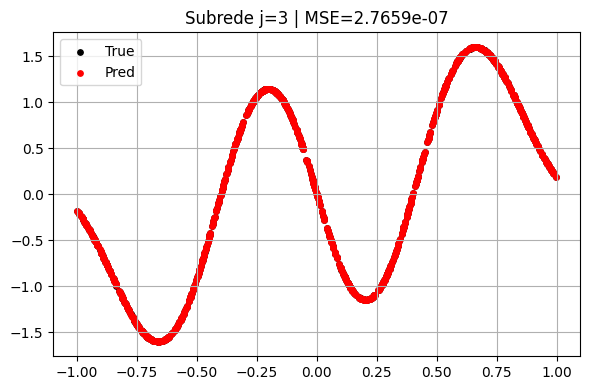

40.00% completado — ~1250.5s restantes

Run 0, 2L, 20N, j=4 → Test MSE = 0.0000192120
Train MSE = 0.0000187713


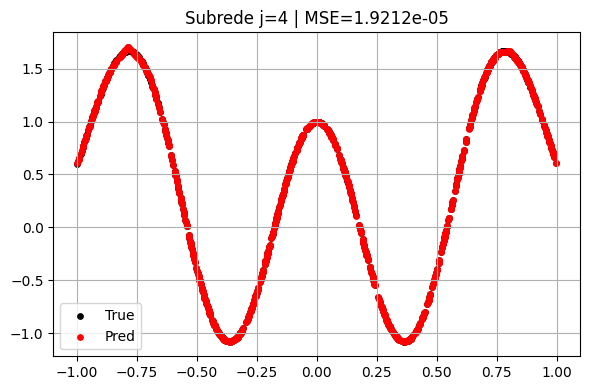

50.00% completado — ~1041.2s restantes

Run 0, 2L, 20N, j=5 → Test MSE = 0.0001959731
Train MSE = 0.0001571625


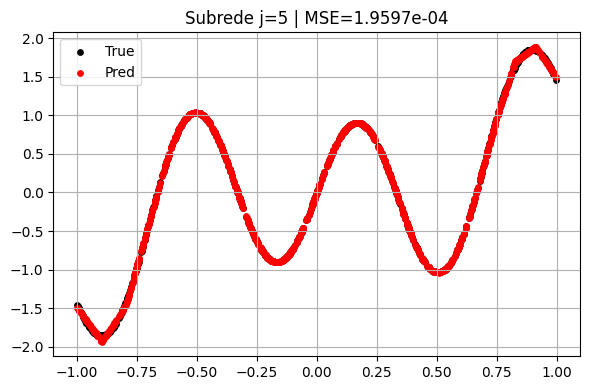

60.00% completado — ~827.6s restantes

Run 0, 2L, 20N, j=6 → Test MSE = 0.0032780417
Train MSE = 0.0034476174


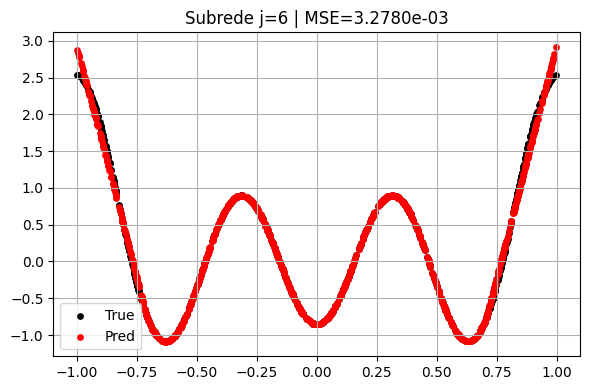

70.00% completado — ~618.7s restantes

Run 0, 2L, 20N, j=7 → Test MSE = 0.0002430281
Train MSE = 0.0002218264


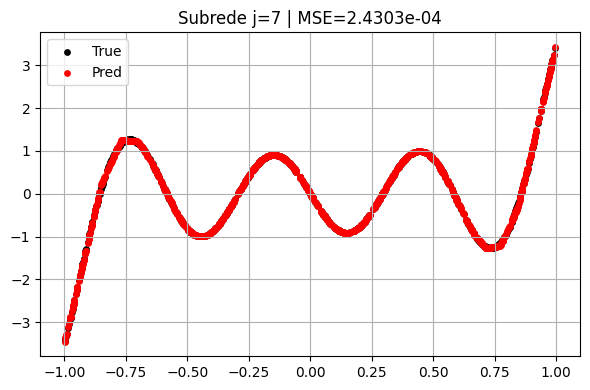

80.00% completado — ~411.7s restantes

Run 0, 2L, 20N, j=8 → Test MSE = 0.0000184651
Train MSE = 0.0000179546


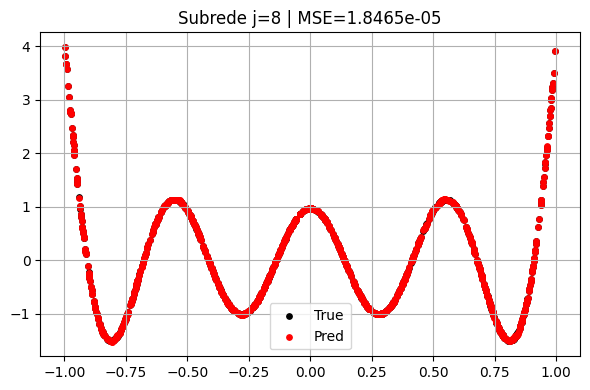

90.00% completado — ~205.3s restantes

Run 0, 2L, 20N, j=9 → Test MSE = 0.0001138298
Train MSE = 0.0001307189


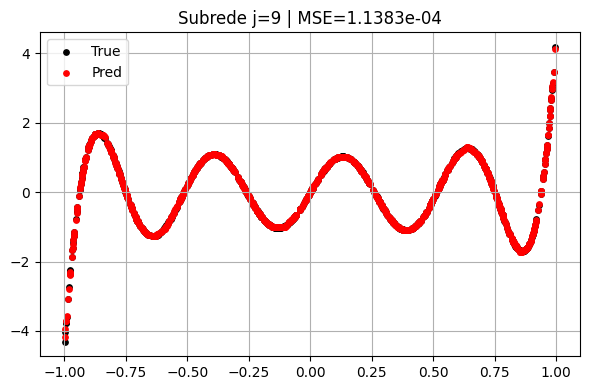

100.00% completado — ~0.0s restantes

✅ Combined model saved: combined_model_run0_i0_k0.keras

🚀 Training new_model_final (run=0, i=0, k=0) epoch by epoch...
Epoch 1/1000 | Train Loss: 2.1418e-03 | Test Loss: 2.5647e-05
Epoch 2/1000 | Train Loss: 1.1553e-05 | Test Loss: 5.4513e-06
Epoch 3/1000 | Train Loss: 4.2164e-06 | Test Loss: 2.7088e-06
Epoch 4/1000 | Train Loss: 2.3348e-06 | Test Loss: 1.7476e-06
Epoch 5/1000 | Train Loss: 1.7201e-06 | Test Loss: 2.7123e-06
Epoch 6/1000 | Train Loss: 1.3647e-06 | Test Loss: 2.0497e-06
Epoch 7/1000 | Train Loss: 1.8996e-06 | Test Loss: 1.0957e-06
Epoch 8/1000 | Train Loss: 8.1335e-07 | Test Loss: 1.6556e-06
Epoch 9/1000 | Train Loss: 9.2248e-07 | Test Loss: 1.0714e-06
Epoch 10/1000 | Train Loss: 9.0208e-07 | Test Loss: 2.3401e-06
Epoch 11/1000 | Train Loss: 5.1096e-06 | Test Loss: 9.3507e-06
Epoch 12/1000 | Train Loss: 1.3145e-05 | Test Loss: 2.8511e-06
Epoch 13/1000 | Train Loss: 4.1104e-06 | Test Loss: 2.5606e-06
Epoch 14/1000 | Train Loss: 3.44

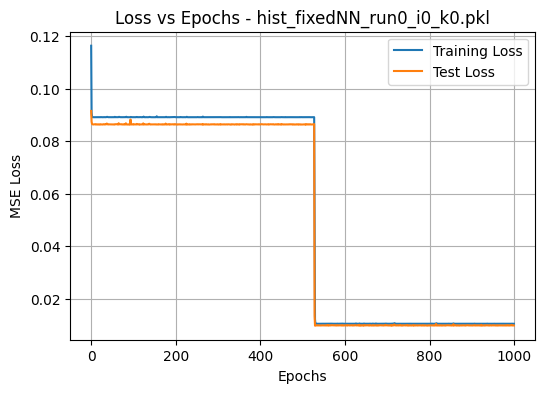

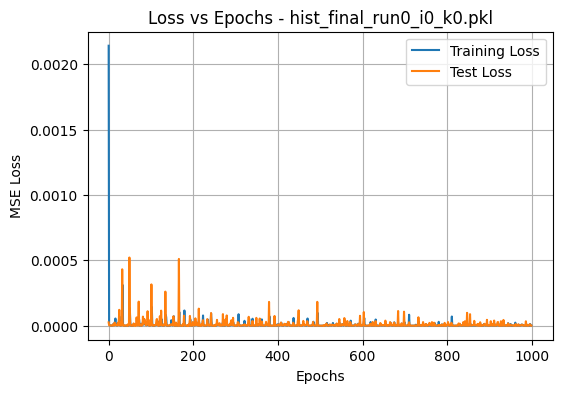

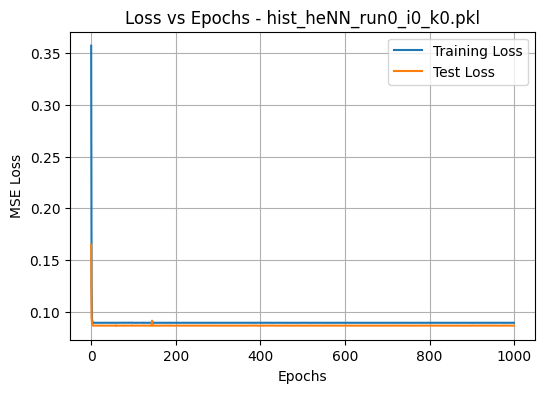

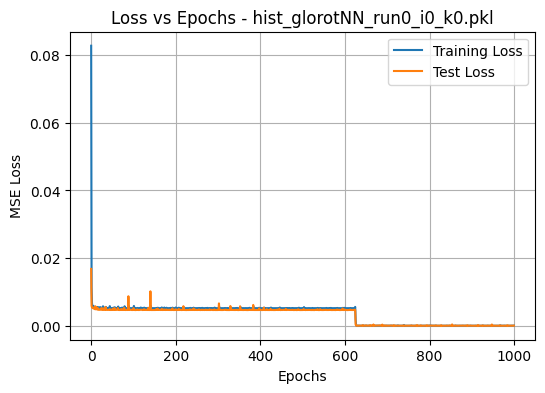

In [45]:
import os
import pickle
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Concatenate

# =============================
# Folders for saving models and vectors
# =============================
output_dir = "Training_Results"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/Models", exist_ok=True)
os.makedirs(f"{output_dir}/X_Vectors", exist_ok=True)

# =============================
# Initial variables
# =============================
start_time = time.time()
total_runs = 1
c = 10
Para_slep_list = list(range(0, Para_slep + 1))

predictions = np.zeros([len(Lay_x_Neu), Nsamples[0], len(Nsamples), total_runs, len(Para_slep_list)])
test_PSWF_matrix_ = np.zeros([len(Lay_x_Neu), Ntest[0], len(Nsamples), total_runs, len(Para_slep_list)])
MSE = np.zeros([len(Lay_x_Neu), len(Nleast2), total_runs])
total_iterations = total_runs * len(Nsamples) * len(Lay_x_Neu) * len(Para_slep_list)
counter = 0

# =============================
# Main loop
# =============================
for run in range(total_runs):
    full_training_set = samps(Nsamples[-1])
    full_test_set = samps(Ntest[0])
    y = funct(full_training_set)
    y_test = funct(full_test_set)

    for i in range(len(Nsamples)):

        for k, neurons in enumerate(Lay_x_Neu):
            subnets_paths = []

            # --- Train subnetworks ---
            for j_index, j_val in enumerate(Para_slep_list):
                if j_val >= len(norms_):
                    continue

                values = PSWF(full_training_set, j_val, c)
                values_test= PSWF(full_test_set, j_val, c)

                # Exponential learning rate
                lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
                    initial_learning_rate=initial_learning_rate,
                    decay_steps=decay_steps,
                    decay_rate=decay_rate,
                    staircase=staircase
                )
                optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-7)

                # --- Train individual subnetwork ---
                model = create_simple_NN(full_training_set, values, Lay_x_Neu[k])
                model.compile(loss="mean_squared_error", optimizer=optimizer, metrics=["mean_squared_error"])
                hist = model.fit(full_training_set, values,
                                 validation_split=VAL_SPLIT,
                                 epochs=final_epochs,
                                 batch_size=BATCH_SIZE,
                                 shuffle=True,
                                 verbose=False)

                # Save subnetwork history
                hist_name = f"hist_subnet_run{run}_i{i}_k{k}_j{j_index}.pkl"
                with open(os.path.join(output_dir, "Models", hist_name), "wb") as f:
                    pickle.dump(hist.history, f)

                # Save subnetwork model
                model_name = f"model_run{run}_i{i}_k{k}_j{j_index}.keras"
                model_path = os.path.join(output_dir, "Models", model_name)
                model.save(model_path)
                subnets_paths.append(model_path)

                # Save predictions
                y_pred = model.predict(full_test_set, verbose=0).flatten()
                predictions[k, :, i, run, j_index] = model.predict(full_training_set, verbose=0).flatten()
                test_PSWF_matrix_[k, :, i, run, j_index] = model.predict(full_test_set, verbose=0).flatten()


                # === 🔹 Evaluation of the testset ===
                test_loss, test_mse = model.evaluate(full_test_set, values_test, verbose=0)
                print(f"Run {run}, 2L, 20N, j={j_index} → Test MSE = {test_mse:.10f}")

                train_loss, train_mse = model.evaluate(full_training_set, values, verbose=0)
                print(f"Train MSE = {train_mse:.10f}")

                # === 🔹 Mostrar función real vs predicha ===
                plt.figure(figsize=(6,4))
                plt.scatter(full_test_set.flatten(), values_test.flatten(), color='k', s=15, label='True')
                plt.scatter(full_test_set.flatten(), y_pred, color='r', s=15, label='Pred')
                plt.title(f'Subrede j={j_index} | MSE={test_mse:.4e}')
                plt.legend()
                plt.grid(True)
                plt.tight_layout()
                plt.show()

                # --- Progreso ---
                counter += 1
                elapsed = time.time() - start_time
                remaining = (total_iterations - counter) * elapsed / counter
                print(f"{100*counter/total_iterations:.2f}% completado — ~{remaining:.1f}s restantes\n")

            # ---- Solve linear regression for x vector ----
            A = predictions[k, :, i, run, :]
            x, _, _, _ = np.linalg.lstsq(A, y, rcond=None)

            # Save x vector
            x_name = f"x_run{run}_i{i}_k{k}.pkl"
            with open(os.path.join(output_dir, "X_Vectors", x_name), "wb") as f:
                pickle.dump(x, f)

            # ---- Create combined model ----
            inputs = Input(shape=(1,))
            sub_outputs = [load_model(path)(inputs) for path in subnets_paths]
            for sm in sub_outputs:
                sm.trainable = False
            concat = Concatenate()(sub_outputs)
            combined_output = Dense(1, use_bias=False,
                                    kernel_initializer=tf.keras.initializers.Constant(x.reshape(-1,1)))(concat)
            combined_model = Model(inputs=inputs, outputs=combined_output)

            combined_model_name = f"combined_model_run{run}_i{i}_k{k}.keras"
            combined_model.save(os.path.join(output_dir, "Models", combined_model_name))
            print(f"✅ Combined model saved: {combined_model_name}")

            # =============================
            # Train new_model_final
            # =============================
            combined_model = load_model(os.path.join(output_dir, "Models", combined_model_name))
            new_model_final = tf.keras.models.clone_model(combined_model)
            new_model_final.build((None,1))
            new_model_final.set_weights(combined_model.get_weights())
            new_model_final.compile(optimizer=Adam(learning_rate=initial_learning_rate),
                                    loss="mean_squared_error", metrics=["mean_squared_error"])

            training_sample_tf = full_training_set.reshape(-1,1)
            y_target_tf = y.reshape(-1,1)
            test_sample_tf = full_test_set.reshape(-1,1)
            y_test_tf = y_test.reshape(-1,1)

            train_loss_final, test_loss_final = [], []

            print(f"\n🚀 Training new_model_final (run={run}, i={i}, k={k}) epoch by epoch...")

            for epoch in range(final_epochs):
                hist = new_model_final.fit(full_training_set, y_target_tf, epochs=1,
                                           batch_size=min(BATCH_SIZE, len(training_sample_tf)),
                                           shuffle=True, verbose=False)
                train_loss = hist.history["loss"][0]
                test_loss = new_model_final.evaluate(test_sample_tf, y_test_tf, verbose=False)[0]

                train_loss_final.append(train_loss)
                test_loss_final.append(test_loss)

                if epoch < 100:
                    print(f"Epoch {epoch+1}/{final_epochs} | Train Loss: {train_loss:.4e} | Test Loss: {test_loss:.4e}")

            # Save history
            history_final_name = f"hist_final_run{run}_i{i}_k{k}.pkl"
            with open(os.path.join(output_dir, "Models", history_final_name), "wb") as f:
                pickle.dump({"train_loss": train_loss_final, "test_loss": test_loss_final}, f)

            new_model_name = f"new_model_run{run}_i{i}_k{k}.keras"
            new_model_final.save(os.path.join(output_dir, "Models", new_model_name))
            print(f"✅ new_model_final trained and saved for run={run}, i={i}, k={k}")

            # =============================
            # Train fixed_model (create_fixed_NN)
            # =============================
            fixed_model = create_fixed_NN()
            fixed_model.compile(optimizer=Adam(learning_rate=initial_learning_rate),
                                loss="mean_squared_error", metrics=["mean_squared_error"])

            train_loss_fixed, test_loss_fixed = [], []

            print(f"\n🚀 Training fixed_model (run={run}, i={i}, k={k}) epoch by epoch...")

            for epoch in range(final_epochs):
                hist = fixed_model.fit(training_sample_tf, y_target_tf, epochs=1,
                                       batch_size=min(BATCH_SIZE, len(training_sample_tf)),
                                       shuffle=True, verbose=False)
                train_loss_fixed.append(hist.history["loss"][0])
                test_loss_fixed.append(fixed_model.evaluate(test_sample_tf, y_test_tf, verbose=False)[0])

                if epoch <100:
                    print(f"Epoch {epoch+1}/{final_epochs} | Train Loss: {train_loss_fixed[-1]:.4e} | Test Loss: {test_loss_fixed[-1]:.4e}")

            # Save fixed_model history
            history_fixed_name = f"hist_fixedNN_run{run}_i{i}_k{k}.pkl"
            with open(os.path.join(output_dir, "Models", history_fixed_name), "wb") as f:
                pickle.dump({"train_loss": train_loss_fixed, "test_loss": test_loss_fixed}, f)

            fixed_model_path = os.path.join(output_dir, "Models", f"fixed_NN_run{run}_i{i}_k{k}.keras")
            fixed_model.save(fixed_model_path)
            print(f"✅ fixed_model trained and saved for run={run}, i={i}, k={k}")

            # =============================
            # 🔹 Train NN HeNormal
            # =============================


            he_model = create_fixed_NN_he()
            he_model.compile(optimizer=Adam(learning_rate=initial_learning_rate),
                             loss="mean_squared_error", metrics=["mean_squared_error"])

            train_loss_he, test_loss_he = [], []

            print(f"\n🚀 Training HeNormal NN (run={run}, i={i}, k={k}) epoch by epoch...")

            for epoch in range(final_epochs):
                hist = he_model.fit(training_sample_tf, y_target_tf, epochs=1,
                                    batch_size=min(BATCH_SIZE, len(training_sample_tf)),
                                    shuffle=True, verbose=False)
                train_loss_he.append(hist.history["loss"][0])
                test_loss_he.append(he_model.evaluate(test_sample_tf, y_test_tf, verbose=False)[0])

                if epoch < 100:
                    print(f"Epoch {epoch+1}/{final_epochs} | Train Loss: {train_loss_he[-1]:.4e} | Test Loss: {test_loss_he[-1]:.4e}")

            # Save history HeNormal
            history_he_name = f"hist_heNN_run{run}_i{i}_k{k}.pkl"
            with open(os.path.join(output_dir, "Models", history_he_name), "wb") as f:
                pickle.dump({"train_loss": train_loss_he, "test_loss": test_loss_he}, f)

            # =============================
            # 🔹 Train NN GlorotUniform
            # =============================


            glorot_model = create_fixed_NN_glorot()
            glorot_model.compile(optimizer=Adam(learning_rate=initial_learning_rate),
                                 loss="mean_squared_error", metrics=["mean_squared_error"])

            train_loss_glorot, test_loss_glorot = [], []

            print(f"\n🚀 Training GlorotUniform NN (run={run}, i={i}, k={k}) epoch by epoch...")

            for epoch in range(final_epochs):
                hist = glorot_model.fit(training_sample_tf, y_target_tf, epochs=1,
                                        batch_size=min(BATCH_SIZE, len(training_sample_tf)),
                                        shuffle=True, verbose=False)
                train_loss_glorot.append(hist.history["loss"][0])
                test_loss_glorot.append(glorot_model.evaluate(test_sample_tf, y_test_tf, verbose=False)[0])

                if epoch < 100:
                    print(f"Epoch {epoch+1}/{final_epochs} | Train Loss: {train_loss_glorot[-1]:.4e} | Test Loss: {test_loss_glorot[-1]:.4e}")

            # Save history GlorotUniform
            history_glorot_name = f"hist_glorotNN_run{run}_i{i}_k{k}.pkl"
            with open(os.path.join(output_dir, "Models", history_glorot_name), "wb") as f:
                pickle.dump({"train_loss": train_loss_glorot, "test_loss": test_loss_glorot}, f)

# =============================
# Plot Training and Test Loss
# =============================
history_files = [f for f in os.listdir(f"{output_dir}/Models") if f.startswith("hist_final_run")
                 or f.startswith("hist_fixedNN_run")
                 or f.startswith("hist_heNN_run")
                 or f.startswith("hist_glorotNN_run")]

for hfile in history_files:
    with open(os.path.join(f"{output_dir}/Models", hfile), "rb") as f:
        history = pickle.load(f)

    plt.figure(figsize=(6,4))
    plt.plot(history["train_loss"], label="Training Loss")
    plt.plot(history["test_loss"], label="Test Loss")
    plt.title(f"Loss vs Epochs - {hfile}")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

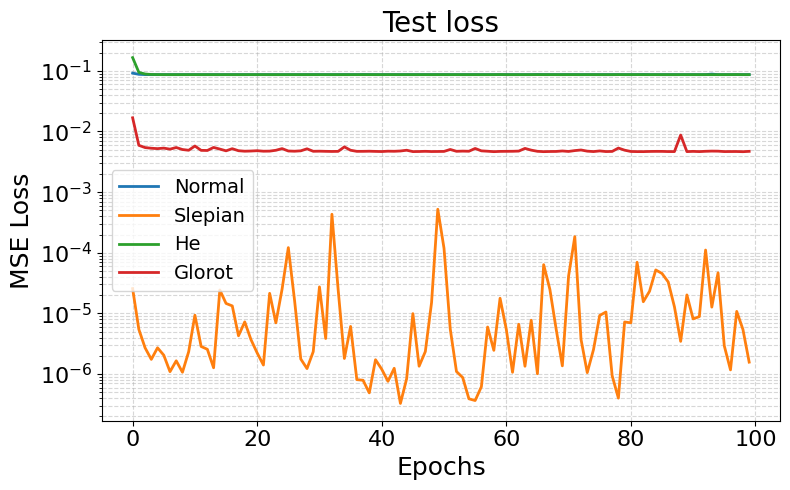

In [46]:
plt.figure(figsize=(8,5))

# Nuevo mapeo de labels simplificado
label_map = {
    "hist_final": "Slepian",
    "hist_fixedNN": "Normal",
    "hist_heNN": "He",
    "hist_glorotNN": "Glorot"
}

for hfile in history_files:

    # Elegir label
    label_to_use = None
    for key in label_map:
        if hfile.startswith(key):
            label_to_use = label_map[key]
            break
    if label_to_use is None:
        label_to_use = hfile.replace(".pkl","")

    # Leer historial
    with open(os.path.join(f"{output_dir}/Models", hfile), "rb") as f:
        history = pickle.load(f)

    # Plot (primeros 100)
    plt.plot(history["test_loss"][:100], label=label_to_use, linewidth=2.0)

# Estética solicitada
plt.yscale("log")                       # <--- log scale en Y
plt.xlabel("Epochs", fontsize=18)
plt.ylabel("MSE Loss", fontsize=18)
plt.title("Test loss", fontsize=20)
plt.tick_params(axis="both", labelsize=16)
plt.legend(fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()

# Guardar
plt.savefig("Exp2_test.pdf")

from google.colab import files
files.download("Exp2_test.pdf")

plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

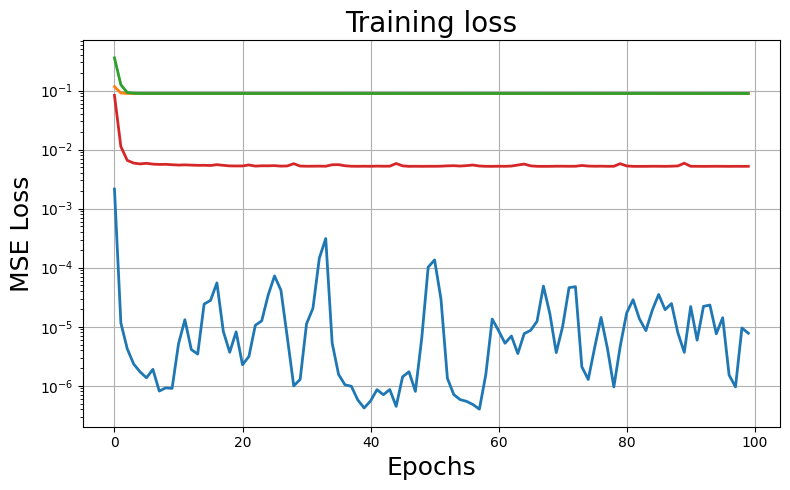

In [47]:
MAX_EPOCHS = 100

# Lista de archivos que quieres graficar
history_files = [
    "hist_final_run0_i0_k0.pkl",
    "hist_fixedNN_run0_i0_k0.pkl",
    "hist_heNN_run0_i0_k0.pkl",
    "hist_glorotNN_run0_i0_k0.pkl"
]

plt.figure(figsize=(8,5))

for hfile in history_files:

    # Elegir label automáticamente
    label_to_use = None
    for key in label_map:
        if hfile.startswith(key):
            label_to_use = label_map[key]
            break
    if label_to_use is None:
        label_to_use = "Unknown Model"

    # Cargar historial
    with open(os.path.join(f"{output_dir}/Models", hfile), "rb") as f:
        history = pickle.load(f)

    # Plot training loss
    plt.plot(history["train_loss"][:MAX_EPOCHS], label=label_to_use, linewidth=2)

plt.xlabel("Epochs", fontsize=18)
plt.ylabel("MSE Loss", fontsize=18)
plt.title("Training loss", fontsize=20)
plt.yscale("log")                      # Por si también quieres log-scale
plt.grid(True)
plt.tight_layout()

# Guardar PDF
plt.savefig("Exp2_training.pdf")

from google.colab import files
files.download("Exp2_training.pdf")

plt.show()


In [48]:
import os
import pickle

# Ruta al historial del método 4
history_file = os.path.join("Training_Results", "Models", "hist_heNN_run0_i0_k0.pkl")

# Cargar historial
with open(history_file, "rb") as f:
    history = pickle.load(f)

# Época 500 (índice 499)
epoch = 499

train_loss_epoch = history["train_loss"][epoch]
test_loss_epoch = history["test_loss"][epoch]

print(f"Epoch 500 | Train Loss: {train_loss_epoch:.6f} | Test Loss: {test_loss_epoch:.6f}")


Epoch 500 | Train Loss: 0.089218 | Test Loss: 0.086348


In [49]:
import os
import pickle

# Carpeta donde están los historiales
history_dir = os.path.join("Training_Results", "Models")

# Filtrar solo los archivos de historial que nos interesan
history_files = [f for f in os.listdir(history_dir) if f.startswith(("hist_final_run", "hist_fixedNN_run", "hist_heNN_run", "hist_glorotNN_run"))]

# Época que queremos (Python indexa desde 0)
epoch = 499  # corresponde a la época 500

# Recorrer archivos y mostrar los resultados
print(f"{'Método':<30} | {'Train Loss':<12} | {'Test Loss':<12}")
print("-"*60)

for hfile in history_files:
    file_path = os.path.join(history_dir, hfile)
    with open(file_path, "rb") as f:
        history = pickle.load(f)

    train_loss = history["train_loss"][epoch]
    test_loss = history["test_loss"][epoch]

    print(f"{hfile:<30} | {train_loss:<12.6f} | {test_loss:<12.6f}")


Método                         | Train Loss   | Test Loss   
------------------------------------------------------------
hist_fixedNN_run0_i0_k0.pkl    | 0.089195     | 0.086401    
hist_final_run0_i0_k0.pkl      | 0.000000     | 0.000000    
hist_heNN_run0_i0_k0.pkl       | 0.089218     | 0.086348    
hist_glorotNN_run0_i0_k0.pkl   | 0.005200     | 0.004666    
